# EDA Notebook
## Alexandru Popovici

Mai intai am importat bibliotecile si am incarcat setul de date. De asemenea am vizualizat forma dataframe ului, dar si tipul datelor care parea sa fie in regula!

In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
url = "https://github.com/ian2004/Alexandru_Popovici_Task04/raw/refs/heads/main/data/cars.csv"
df = pd.read_csv(url)
df

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B
...,...,...,...,...,...,...,...,...,...,...,...,...
56239,lancia,zeta,3650,2000,with mileage,290000.0,petrol,2000.0,other,mechanics,front-wheel drive,M
56240,lancia,zeta,4100,1999,with mileage,340000.0,diesel,2100.0,blue,mechanics,front-wheel drive,M
56241,lancia,zeta,3600,1997,with mileage,354000.0,diesel,2100.0,burgundy,mechanics,front-wheel drive,M
56242,lancia,zeta,3000,1997,with mileage,350000.0,petrol,2000.0,blue,mechanics,front-wheel drive,M


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  str    
 1   model                56244 non-null  str    
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  str    
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  str    
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  str    
 9   transmission         56244 non-null  str    
 10  drive_unit           54339 non-null  str    
 11  segment              50953 non-null  str    
dtypes: float64(2), int64(2), str(8)
memory usage: 5.1 MB


# Vizualizarea datelor lipsa
A trebuit sa vizualizez ce date lipsesc, iar mai incolo, in cazul in care datele din coloane influenteaza pretul acestea ar trebuii intr-un script ulterior sa fie curatate. 

In [6]:
df.isna().sum()

make                      0
model                     0
priceUSD                  0
year                      0
condition                 0
mileage(kilometers)       0
fuel_type                 0
volume(cm3)              47
color                     0
transmission              0
drive_unit             1905
segment                5291
dtype: int64

# Analizarea datelor din coloana priceUSD
In acest pas am vrut sa ma asigur ca valorile din coloana **priceUSD** par in regula pentru a putea sa le integrez in model

In [7]:
df["priceUSD"].unique()

array([5500, 5350, 7000, ..., 5012, 3922, 4492], shape=(2970,))

In [8]:
print(df["priceUSD"].min())
print(df["priceUSD"].max())

48
235235


Aici am analizat valorile numerice care for fi folosite mai tarziu pentru 

In [9]:
df.describe().round(2)

,priceUSD,year,mileage(kilometers),volume(cm3)
count,56244.00,56244.00,56244.00,56197.00
mean,7415.46,2003.45,244395.63,2104.86
std,8316.96,8.14,321030.67,959.20
min,48.00,1910.00,0.00,500.00
25%,2350.00,1998.00,137000.00,1600.00
50%,5350.00,2004.00,228500.00,1996.00
75%,9807.50,2010.00,310000.00,2300.00
max,235235.00,2019.00,9999999.00,20000.00


Desigur ca am observat faptul unele preturi sunt surprinzator de mici, normal pentru masini avariate sau care se vand pe "bucati" pentru piese, dar si mileage de 0 km care nu are sens in conditia in care acestea sunt trecute la condition ca "with mileage", iar unele valori sar peste 9 milioane de kilometrii, aceste valori pot afecta predictia facuta de model

In [10]:
df[df["mileage(kilometers)"] == 0]

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
184,mazda,3,5500,2007,with mileage,0.0,petrol,1600.0,silver,mechanics,front-wheel drive,C
809,renault,19,209,1991,for parts,0.0,petrol,1700.0,brown,mechanics,front-wheel drive,C
863,gaz,21,999,1961,with mileage,0.0,petrol,2400.0,gray,mechanics,front-wheel drive,E
910,renault,21,500,1992,with mileage,0.0,diesel,1900.0,red,mechanics,front-wheel drive,D
1009,uaz,31,1300,1994,with mileage,0.0,petrol,2400.0,gray,mechanics,part-time four-wheel drive,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
55084,citroen,xsara,1700,1999,with mileage,0.0,petrol,1800.0,silver,mechanics,front-wheel drive,C
55523,toyota,yaris,3400,2004,with mileage,0.0,petrol,1000.0,silver,mechanics,front-wheel drive,B
55638,opel,zafira,4450,2002,with mileage,0.0,diesel,2000.0,black,mechanics,front-wheel drive,M
55711,opel,zafira,4100,2002,with mileage,0.0,diesel,2200.0,gray,mechanics,front-wheel drive,M


In [11]:
df[df["mileage(kilometers)"] < 100]

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
184,mazda,3,5500,2007,with mileage,0.0,petrol,1600.0,silver,mechanics,front-wheel drive,C
443,mazda,6,10370,2013,with mileage,11.0,petrol,1998.0,black,auto,front-wheel drive,D
708,renault,19,181,1993,for parts,1.0,petrol,1390.0,red,mechanics,NaN,C
756,renault,19,550,1995,with mileage,22.0,petrol,1400.0,red,mechanics,front-wheel drive,C
809,renault,19,209,1991,for parts,0.0,petrol,1700.0,brown,mechanics,front-wheel drive,C
...,...,...,...,...,...,...,...,...,...,...,...,...
55747,opel,zafira,4300,2000,with mileage,17.0,petrol,1800.0,blue,mechanics,front-wheel drive,M
55795,opel,zafira,4400,2000,with mileage,0.0,petrol,1800.0,black,mechanics,NaN,M
56170,opel,zafira,9000,2011,with mileage,10.0,petrol,1800.0,gray,auto,NaN,M
56226,lancia,zeta,2500,1996,with mileage,3.0,petrol,2000.0,burgundy,mechanics,front-wheel drive,M


In [12]:
df[df["mileage(kilometers)"] > 5250000.00]

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
1165,audi,80,3000,1993,with mileage,5555555.0,diesel,1900.0,white,mechanics,front-wheel drive,D
1394,audi,80,500,1986,with mileage,9999999.0,petrol,1800.0,silver,mechanics,front-wheel drive,D
1744,audi,100,1500,1989,with mileage,6666666.0,diesel,1900.0,silver,mechanics,front-wheel drive,E
1854,audi,100,900,1989,with mileage,9999999.0,petrol,2300.0,white,mechanics,front-wheel drive,E
1875,audi,100,2500,1989,with mileage,5445558.0,diesel,2500.0,black,mechanics,front-wheel drive,E
3890,peugeot,405,230,1989,for parts,6110707.0,petrol,1900.0,gray,mechanics,front-wheel drive,D
3950,peugeot,405,428,1991,with mileage,6666666.0,diesel,1900.0,gray,mechanics,front-wheel drive,D
4994,rover,600,800,1999,with mileage,5555555.0,diesel,2000.0,blue,mechanics,front-wheel drive,E
5783,peugeot,806,4100,2000,with mileage,9999999.0,diesel,2000.0,silver,mechanics,front-wheel drive,M
6114,lada-vaz,2104,600,1990,with mileage,9999999.0,petrol,1500.0,red,mechanics,rear drive,B


Aceste valori sunt gresite avand in vedere faptul ca recordul mondial pentru cel mai mare milage este de 5.25 milioane de kilometrii, astfel aceastea trebuie eliminate. De asemenea sunt multe masini din 96 de exemplu care au un kilometraj de 9 sau 3 sau 4 deci sunt suspecte

# Aflarea True Mileage

In [13]:
max_year = 2019

df["car_age"] = max_year - df["year"]
df["km_per_year"] = df["mileage(kilometers)"] / df["car_age"].clip(lower=1)

In [14]:
df[df["km_per_year"] < 100]

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment,car_age,km_per_year
37,mazda,3,4750,2004,with mileage,139.00000,petrol,2000.0,silver,auto,front-wheel drive,C,15,9.266667
136,mazda,3,5489,2008,with mileage,300.94658,petrol,2000.0,silver,auto,front-wheel drive,C,11,27.358780
184,mazda,3,5500,2007,with mileage,0.00000,petrol,1600.0,silver,mechanics,front-wheel drive,C,12,0.000000
206,mazda,3,5500,2007,with mileage,213.00000,petrol,1598.0,other,auto,front-wheel drive,C,12,17.750000
237,mazda,3,4100,2005,with mileage,267.00000,petrol,1600.0,gray,auto,NaN,C,14,19.071429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56204,opel,zafira,4200,2000,with mileage,280.00000,petrol,1800.0,blue,mechanics,front-wheel drive,M,19,14.736842
56225,lancia,zeta,4100,1999,with mileage,400.00000,diesel,2000.0,blue,mechanics,front-wheel drive,M,20,20.000000
56226,lancia,zeta,2500,1996,with mileage,3.00000,petrol,2000.0,burgundy,mechanics,front-wheel drive,M,23,0.130435
56236,lancia,zeta,3500,1996,with mileage,160.00000,petrol,2000.0,blue,mechanics,front-wheel drive,M,23,6.956522


In [15]:
df[df["km_per_year"] > 100000]

,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment,car_age,km_per_year
771,renault,19,600,1995,with mileage,2500000.0,petrol,1800.0,black,mechanics,front-wheel drive,C,24,104166.666667
1113,audi,80,1400,1986,with mileage,3700490.0,diesel,1600.0,yellow,mechanics,front-wheel drive,D,33,112136.060606
1165,audi,80,3000,1993,with mileage,5555555.0,diesel,1900.0,white,mechanics,front-wheel drive,D,26,213675.192308
1394,audi,80,500,1986,with mileage,9999999.0,petrol,1800.0,silver,mechanics,front-wheel drive,D,33,303030.272727
1400,audi,80,1500,1988,with mileage,3700000.0,petrol,1800.0,black,mechanics,front-wheel drive,D,31,119354.838710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55359,citroen,xsara-picasso,3500,2001,with mileage,3748301.0,petrol,1800.0,burgundy,mechanics,front-wheel drive,C,18,208238.944444
55703,opel,zafira,4000,1999,with mileage,3600000.0,petrol,1800.0,blue,mechanics,front-wheel drive,M,20,180000.000000
56113,opel,zafira,4850,2004,with mileage,4444444.0,petrol,1600.0,white,mechanics,front-wheel drive,M,15,296296.266667
56160,opel,zafira,4400,2002,with mileage,3333333.0,diesel,2000.0,silver,mechanics,front-wheel drive,M,17,196078.411765


Eliminand aceste valori suspecte putem calibra mai bine modelul nostru pentru a fi mai performant

# Analiza corelatiei intre coloana priceUSD si celelalte coloane pentru a vedea daca aceastea influenteaza pretul
Coloanele care influenteaza pretul pot fi folosite la scriptul de feature engeneering pentru a imbunatatii acuratetea predictiei facute de model

In [16]:
df.columns.tolist()

['make',
 'model',
 'priceUSD',
 'year',
 'condition',
 'mileage(kilometers)',
 'fuel_type',
 'volume(cm3)',
 'color',
 'transmission',
 'drive_unit',
 'segment',
 'car_age',
 'km_per_year']

In [17]:
df["condition"].unique()

<StringArray>
['with mileage', 'with damage', 'for parts']
Length: 3, dtype: str

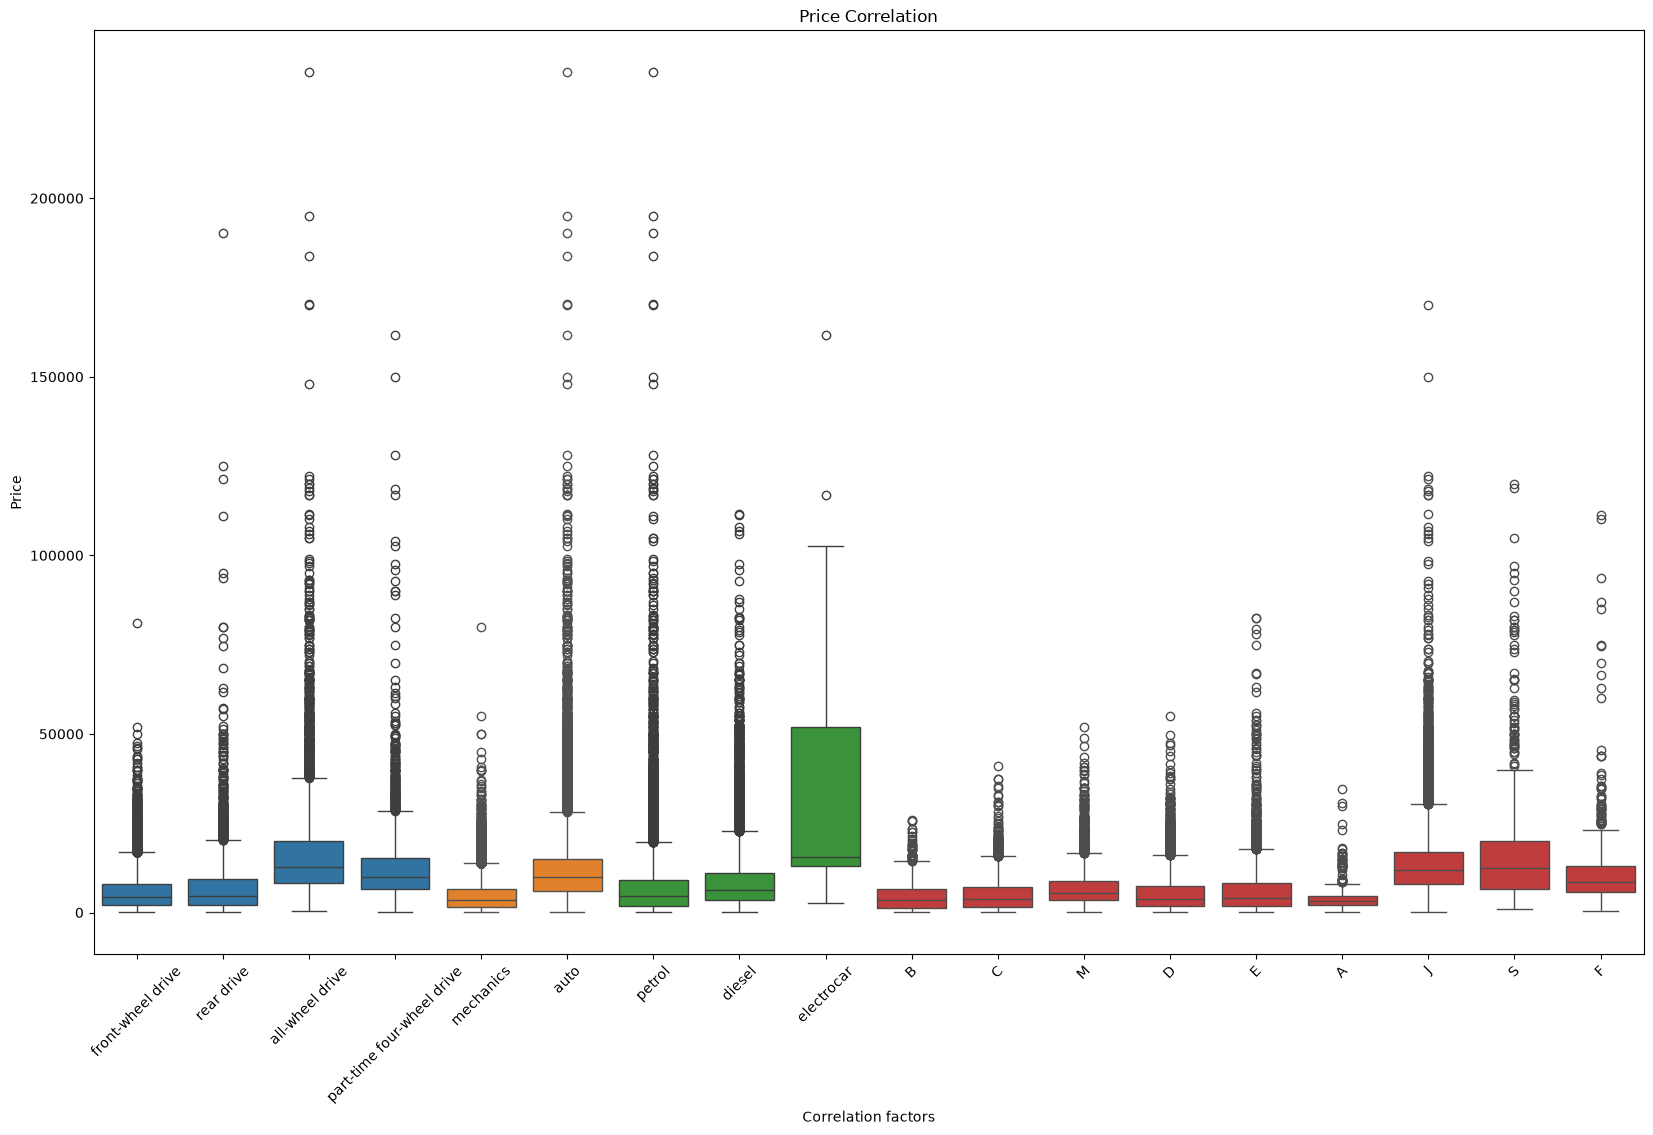

In [18]:
lista_coloane = [df["drive_unit"], df["transmission"], df["fuel_type"], df["segment"]]
plt.figure(figsize=(20, 12))
for i in lista_coloane:
    sns.boxplot(x = i, y= df["priceUSD"])
    plt.xticks(rotation = 45)
    plt.title("Price Correlation")
    plt.xlabel("Correlation factors")
    plt.ylabel("Price")

Putem observa faptul ca pe langa coloanele **df["model"]**, **df["year"]**, **df["condition"]**, **df["volume(cm3)"]** si **df["make"]** care clar ar trebuii sa influenteze pretul, mai avem si coloanele **df["drive_unit"]**, **df["transmission"]**, **df["fuel_type"]**, **df["segment"]** care au un impact asupra pretului si pot fi folosite la feature engeneering

In [19]:
df.isna().sum()

make                      0
model                     0
priceUSD                  0
year                      0
condition                 0
mileage(kilometers)       0
fuel_type                 0
volume(cm3)              47
color                     0
transmission              0
drive_unit             1905
segment                5291
car_age                   0
km_per_year               0
dtype: int64

Asadar pentru imbunatatirea acuratetii modelului trebuie sa curatam coloanele df["volume(cm3)"], df["drive_unit"], df["segment"]

Deoarece culoarea masinii nu prea este luata in calcul la pret, in special daca masina este cumparata second hand, am hotarat ca aceasta coloana ar trebuii sa fie stearsa in scriptul de datacleaning, ramananand astfel cu restul de coloane

# Analiza catregoriilor

In [20]:
for i in df.columns.tolist():
    print(df[i].unique())

<StringArray>
[         'mazda',             'mg',        'renault',            'gaz',
            'aro',          'rover',            'uaz',     'alfa-romeo',
           'audi',     'oldsmobile',           'saab',        'peugeot',
       'chrysler',       'wartburg',       'moskvich',          'volvo',
           'fiat',          'roewe',        'porsche',            'zaz',
           'luaz',          'dacia',       'lada-vaz',            'izh',
            'raf',         'bogdan',            'bmw',         'nissan',
  'mercedes-benz',     'mitsubishi',         'toyota',          'chery',
            'gmc',        'hyundai',          'honda',      'ssangyong',
         'suzuki',           'opel',           'seat',     'volkswagen',
       'daihatsu',      'chevrolet',          'geely',         'saturn',
            'kia',        'lincoln',     'eksklyuziv',        'citroen',
      'dong-feng',        'pontiac',           'ford',         'subaru',
        'bentley',            'faw', 

In [21]:
df.duplicated().sum()

np.int64(87)

In dataset exista duplicate care poate creste artificial acuratetea modelului. Desi aceste nu sunt multe in raport cu setul de date (87 din 56244) aceste ar trebuii curatate odata cu alte valori care ar putea afecta modelul

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  str    
 1   model                56244 non-null  str    
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  str    
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  str    
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  str    
 9   transmission         56244 non-null  str    
 10  drive_unit           54339 non-null  str    
 11  segment              50953 non-null  str    
 12  car_age              56244 non-null  int64  
 13  km_per_year          56244 non-null  float64
dtypes: float64(3), int64(3), str(8)
memory usage: 6.0 MB


In [23]:
categorical_columns = [
    "make",
    "model",
    "condition",
    "fuel_type",
    "transmission",
    "drive_unit",
    "segment"
]

In [24]:
for column in categorical_columns:
    print(column)
    print(df[column].nunique())
    print("-" * 40)

make
96
----------------------------------------
model
1034
----------------------------------------
condition
3
----------------------------------------
fuel_type
3
----------------------------------------
transmission
2
----------------------------------------
drive_unit
4
----------------------------------------
segment
9
----------------------------------------


In [25]:
for column in categorical_columns:
    print(column)
    print(df[column].value_counts(dropna=False))
    print("-" * 40)

make
make
volkswagen    6861
audi          4030
bmw           4013
opel          3779
renault       3713
              ... 
trabant          1
jac              1
asia             1
tagaz            1
saipa            1
Name: count, Length: 96, dtype: int64
----------------------------------------
model
model
passat      2086
5-seriya    1476
a6          1276
golf        1070
astra       1013
            ... 
xb             1
xc40           1
xjs            1
xt5            1
z3             1
Name: count, Length: 1034, dtype: int64
----------------------------------------
condition
condition
with mileage    55278
with damage       512
for parts         454
Name: count, dtype: int64
----------------------------------------
fuel_type
fuel_type
petrol        36405
diesel        19792
electrocar       47
Name: count, dtype: int64
----------------------------------------
transmission
transmission
mechanics    36056
auto         20188
Name: count, dtype: int64
--------------------------------

Vedem ca categoriile arata in regula si aceste nu trebuie standardizate deoarece nu exista de exemplu aceleasi branduri si modele dar scrise diferit si toate sunt cu litere mici mai putin cele din df["segment"] , deci respecta cerintele de standardizare

In [28]:
import numpy as np
np.isinf(df["priceUSD"]).sum()

np.int64(0)

Coloana priceUSD nu are valori "infinite"